In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class State(TypedDict):
    text: str
    summary: str
    sentiment: str
    keywords: str

In [3]:
# Node 1
def summarize(state):
    return {"summary": "Short summary of text"}

In [4]:
# Node 2
def sentiment(state):
    return {"sentiment": "Positive / Negative"}


In [5]:
# Node 3
def keywords(state):
    return {"keywords": "AI, ML, Data"}

In [6]:
# Build graph
graph = StateGraph(State)

graph.add_node("summarize", summarize)
graph.add_node("sentiment", sentiment)
graph.add_node("keywords", keywords)

# Parallel edges
graph.add_edge(START, "summarize")
graph.add_edge(START, "sentiment")
graph.add_edge(START, "keywords")

# Merge to END
graph.add_edge("summarize", END)
graph.add_edge("sentiment", END)
graph.add_edge("keywords", END)

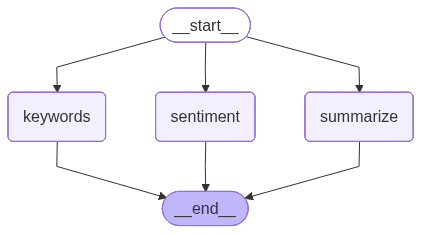

In [7]:
graph.compile()

In [8]:
workflow = graph.compile()

In [9]:
# Run
result = workflow.invoke({"text": "AI is transforming the world"})
print(result)

{'text': 'AI is transforming the world', 'summary': 'Short summary of text', 'sentiment': 'Positive / Negative', 'keywords': 'AI, ML, Data'}
